# Tópico 1: Python_Atividade1

Disciplina: Projeto e Análise de Algoritmos.  
Professor: André Tavares da Silva.  
Aluno: Dalton Solano dos Reis.  

## Enunciado

[PAA_TrabalhoPratico1_Ordenacao.pdf](./PAA_TrabalhoPratico1_Ordenacao.pdf)

Este notebook reúne a implementação pedida no enunciado em células separadas: leitura do arquivo, BubbleSort com contagem de operações e geração dos casos de teste.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
import random
from time import perf_counter
from pathlib import Path


def carregar_valores(caminho_arquivo: str | Path) -> list[int]:
    caminho = Path(caminho_arquivo)
    valores: list[int] = []

    with caminho.open("r", encoding="utf-8") as arquivo:
        for numero_linha, linha in enumerate(arquivo, start=1):
            conteudo = linha.strip()

            if conteudo == "":
                break

            try:
                valores.append(int(conteudo))
            except ValueError as exc:
                raise ValueError(
                    f"Valor invalido na linha {numero_linha}: {conteudo!r}"
                ) from exc

    return valores


def bubblesort_operacoes(valores: list[int]) -> int:
    operacoes = 0
    tamanho = len(valores)

    for i in range(tamanho - 1):
        houve_troca = False

        for j in range(tamanho - 1 - i):
            operacoes += 1

            if valores[j] > valores[j + 1]:
                valores[j], valores[j + 1] = valores[j + 1], valores[j]
                houve_troca = True

        if not houve_troca:
            break

    return operacoes


def executar_bubblesort_arquivo(caminho_arquivo: str | Path) -> dict[str, str | int | float]:
    caminho = Path(caminho_arquivo)
    valores = carregar_valores(caminho)
    inicio = perf_counter()
    operacoes = bubblesort_operacoes(valores)
    tempo_segundos = perf_counter() - inicio

    tipo, tamanho = caminho.stem.split("_")
    resultado = {
        "arquivo": caminho.name,
        "tipo": tipo,
        "tamanho": int(tamanho),
        "operacoes": operacoes,
        "tempo_segundos": tempo_segundos,
    }

    print(
        f"{caminho.name}: {operacoes} operações em {tempo_segundos:.6f} s"
    )
    return resultado


In [2]:
TAMANHOS_PADRAO = (100, 1000, 10000, 100000)


def escrever_valores(caminho: str | Path, valores: list[int]) -> None:
    caminho = Path(caminho)

    with caminho.open("w", encoding="utf-8") as arquivo:
        for valor in valores:
            arquivo.write(f"{valor}\n")
        arquivo.write("\n")


def gerar_arquivos_teste(
    destino: str | Path = "casos_teste",
    tamanhos: tuple[int, ...] = TAMANHOS_PADRAO,
    semente: int = 42,
) -> None:
    random.seed(semente)
    destino_path = Path(destino)
    destino_path.mkdir(parents=True, exist_ok=True)

    for tamanho in tamanhos:
        base = list(range(1, tamanho + 1))
        escrever_valores(destino_path / f"ordenado_{tamanho}.txt", base)
        escrever_valores(destino_path / f"decrescente_{tamanho}.txt", list(reversed(base)))

        randomico = base[:]
        random.shuffle(randomico)
        escrever_valores(destino_path / f"randomico_{tamanho}.txt", randomico)

    print(f"Arquivos gerados em: {destino_path.resolve()}")


__ Casos de teste: DECRESCENTE
decrescente_100.txt: 4950 operações em 0.001068 s
decrescente_1000.txt: 499500 operações em 0.052872 s
decrescente_10000.txt: 49995000 operações em 6.137698 s
decrescente_100000.txt: 4999950000 operações em 694.555670 s

__ Casos de teste: ORDENADO
ordenado_100.txt: 99 operações em 0.000006 s
ordenado_1000.txt: 999 operações em 0.000048 s
ordenado_10000.txt: 9999 operações em 0.000497 s
ordenado_100000.txt: 99999 operações em 0.005195 s

__ Casos de teste: RANDÔMICO
randomico_100.txt: 4940 operações em 0.000391 s
randomico_1000.txt: 497355 operações em 0.042242 s
randomico_10000.txt: 49992585 operações em 4.701250 s
randomico_100000.txt: 4999906635 operações em 640.823357 s



,arquivo,tipo,tamanho,operacoes,tempo_segundos,tempo_ms
0,decrescente_100.txt,decrescente,100,4950,0.001068,1.068458
1,decrescente_1000.txt,decrescente,1000,499500,0.052872,52.871750
2,decrescente_10000.txt,decrescente,10000,49995000,6.137698,6137.698292
3,decrescente_100000.txt,decrescente,100000,4999950000,694.555670,694555.670375
4,ordenado_100.txt,ordenado,100,99,0.000006,0.005625
5,ordenado_1000.txt,ordenado,1000,999,0.000048,0.047916
6,ordenado_10000.txt,ordenado,10000,9999,0.000497,0.496833
7,ordenado_100000.txt,ordenado,100000,99999,0.005195,5.195167
8,randomico_100.txt,randomico,100,4940,0.000391,0.390792
9,randomico_1000.txt,randomico,1000,497355,0.042242,42.242417


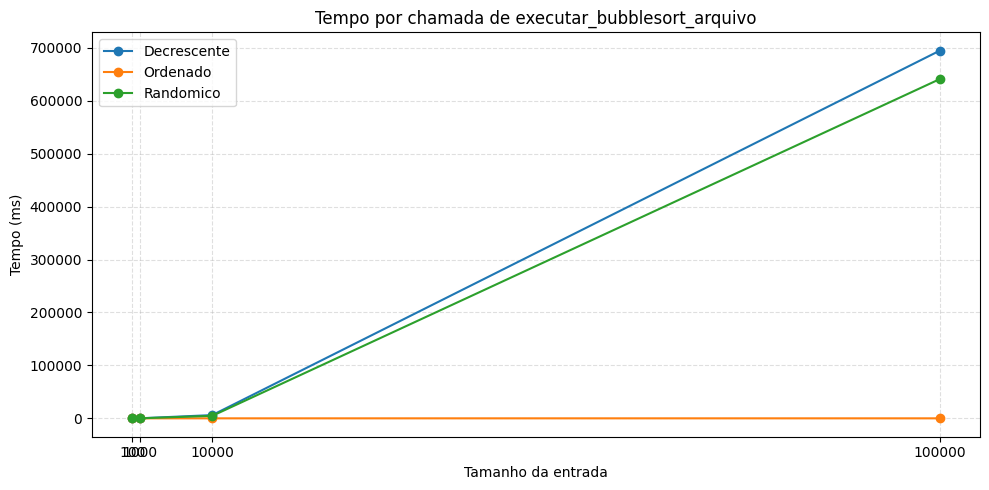

,arquivo,tipo,tamanho,operacoes,tempo_segundos,tempo_ms
0,decrescente_100.txt,decrescente,100,4950,0.001068,1.068458
1,decrescente_1000.txt,decrescente,1000,499500,0.052872,52.871750
2,decrescente_10000.txt,decrescente,10000,49995000,6.137698,6137.698292
3,decrescente_100000.txt,decrescente,100000,4999950000,694.555670,694555.670375
4,ordenado_100.txt,ordenado,100,99,0.000006,0.005625
5,ordenado_1000.txt,ordenado,1000,999,0.000048,0.047916
6,ordenado_10000.txt,ordenado,10000,9999,0.000497,0.496833
7,ordenado_100000.txt,ordenado,100000,99999,0.005195,5.195167
8,randomico_100.txt,randomico,100,4940,0.000391,0.390792
9,randomico_1000.txt,randomico,1000,497355,0.042242,42.242417


In [3]:
# gerar_arquivos_teste()

grupos_arquivos = {
    "Decrescente": [
        "casos_teste/decrescente_100.txt",
        "casos_teste/decrescente_1000.txt",
        "casos_teste/decrescente_10000.txt",
        "casos_teste/decrescente_100000.txt",
    ],
    "Ordenado": [
        "casos_teste/ordenado_100.txt",
        "casos_teste/ordenado_1000.txt",
        "casos_teste/ordenado_10000.txt",
        "casos_teste/ordenado_100000.txt",
    ],
    "Randômico": [
        "casos_teste/randomico_100.txt",
        "casos_teste/randomico_1000.txt",
        "casos_teste/randomico_10000.txt",
        "casos_teste/randomico_100000.txt",
    ],
}

resultados = []

for descricao, arquivos in grupos_arquivos.items():
    print(f"__ Casos de teste: {descricao.upper()}")
    for arquivo in arquivos:
        resultados.append(executar_bubblesort_arquivo(arquivo))
    print()

quadro_tempos = (
    pd.DataFrame(resultados)
    .sort_values(["tipo", "tamanho"])
    .reset_index(drop=True)
)
quadro_tempos["tempo_ms"] = quadro_tempos["tempo_segundos"] * 1000

display(quadro_tempos[["arquivo", "tipo", "tamanho", "operacoes", "tempo_segundos", "tempo_ms"]])

plt.figure(figsize=(10, 5))
for tipo, grupo in quadro_tempos.groupby("tipo"):
    plt.plot(grupo["tamanho"], grupo["tempo_ms"], marker="o", label=tipo.capitalize())

plt.title("Tempo por chamada de executar_bubblesort_arquivo")
plt.xlabel("Tamanho da entrada")
plt.ylabel("Tempo (ms)")
plt.xticks(quadro_tempos["tamanho"].unique())
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

quadro_tempos
